# 6. Modeling Iteration

Enhance feature representation to capture context, while applying a controlled iteration process to improve model performance.

## 6.0. Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [ ]:
neiss_2024_analysis = pd.read_csv('../clean_data/neiss_2024_analysis.csv')

neiss_2024_analysis.head(2).T


,0,1
cpsc_case_number,240108461,240108462
treatment_date,2024-01-01,2024-01-01
age_year,16.0,56.0
sex,male,female
race,unknown,white
hispanic,yes,no
body_part,shoulder,finger
diagnosis,"strain, sprain",laceration
location,place of recreation or sports,home
fire_involvement,no_fire_or_not_recorded,no_fire_or_not_recorded


## 6.1 Data Split Strategy (Train / Validation / Test)

To ensure proper evaluation, the dataset is split into three parts:

- Training set: used to train models
- Validation set: used to compare different modeling strategies
- Test set: used only once for final evaluation

In [ ]:
df = neiss_2024_analysis.copy()

X = df.drop(columns=['admitted'])
y = df['admitted']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

## 6.2 Baseline Model (Validation Version)

We reconstruct the baseline model using validation instead of test data.

In [ ]:
basic_features = [
    'age_group',
    'sex',
    'body_part',
    'diagnosis',
    'location',
    'fire_involvement'
]

def prepare_data(X, features):
    return pd.get_dummies(X[features], drop_first=True)

X_train_base = prepare_data(X_train, basic_features)
X_val_base = prepare_data(X_val, basic_features)

X_val_base = X_val_base.reindex(columns=X_train_base.columns, fill_value=0)


### 6.2.1 Train Baseline

In [ ]:
model_base = LogisticRegression(max_iter=1000)
model_base.fit(X_train_base, y_train)


LogisticRegression(max_iter=1000)

### 6.2.2 Validation Performance

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, recall_score

y_val_pred_base = model_base.predict(X_val_base)
y_val_prob_base = model_base.predict_proba(X_val_base)[:, 1]

print(classification_report(y_val, y_val_pred_base))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_base))

recall_base = recall_score(y_val, y_val_pred_base)


              precision    recall  f1-score   support

           0       0.91      0.98      0.94     47861
           1       0.63      0.24      0.35      6332

    accuracy                           0.89     54193
   macro avg       0.77      0.61      0.65     54193
weighted avg       0.87      0.89      0.87     54193

ROC-AUC: 0.8486828559905188


## 6.3 Iteration 1 — Class Weighting

To address class imbalance, we apply class weighting.

In [ ]:
model_w = LogisticRegression(max_iter=1000, class_weight='balanced')
model_w.fit(X_train_base, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

### 6.3.2 Validation performance

In [ ]:
y_val_pred_w = model_w.predict(X_val_base)
y_val_prob_w = model_w.predict_proba(X_val_base)[:, 1]

print(classification_report(y_val, y_val_pred_w))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_w))

recall_w = recall_score(y_val, y_val_pred_w)


              precision    recall  f1-score   support

           0       0.96      0.75      0.85     47861
           1       0.30      0.79      0.43      6332

    accuracy                           0.76     54193
   macro avg       0.63      0.77      0.64     54193
weighted avg       0.89      0.76      0.80     54193

ROC-AUC: 0.850476993923879


## 6.4 Iteration 2 — Feature Enhancement (Context + Interaction)

We introduce additional contextual features and one interaction term.

### 6.4.1 Feature Engineering

In [ ]:
df_fe = df.copy()

# Contextual features
df_fe['is_weekend'] = df_fe['weekday'].isin(['Saturday', 'Sunday']).astype(int)

df_fe['alcohol_flag'] = (df_fe['alcohol'] != 'no/no information').astype(int)
df_fe['drug_flag'] = (df_fe['drug'] != 'no/no information').astype(int)

df_fe['narrative_len'] = df_fe['narrative_1'].str.len()

# Interaction
df_fe['age_x_diagnosis'] = df_fe['age_group'] + "_" + df_fe['diagnosis']


### 6.4.2  New feature set

In [ ]:
features_v2 = basic_features + [
    'is_weekend',
    'alcohol_flag',
    'drug_flag',
    'narrative_len',
    'age_x_diagnosis'
]


### 6.4.3  Prepare data

In [ ]:
X_train_fe = df_fe.loc[X_train.index]
X_val_fe = df_fe.loc[X_val.index]

X_train_v2 = prepare_data(X_train_fe, features_v2)
X_val_v2 = prepare_data(X_val_fe, features_v2)

X_val_v2 = X_val_v2.reindex(columns=X_train_v2.columns, fill_value=0)


### 6.4.4  Train model

In [ ]:
model_v2 = LogisticRegression(max_iter=1000, class_weight='balanced')
model_v2.fit(X_train_v2, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

### 6.4.5  Validation performance

In [ ]:
y_val_pred_v2 = model_v2.predict(X_val_v2)
y_val_prob_v2 = model_v2.predict_proba(X_val_v2)[:, 1]

print(classification_report(y_val, y_val_pred_v2))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_v2))

recall_v2 = recall_score(y_val, y_val_pred_v2)


              precision    recall  f1-score   support

           0       0.97      0.75      0.84     47861
           1       0.30      0.81      0.44      6332

    accuracy                           0.75     54193
   macro avg       0.63      0.78      0.64     54193
weighted avg       0.89      0.75      0.80     54193

ROC-AUC: 0.8562367523594299


## 6.5 Model Comparison (Validation)

,Model,Recall (Admitted),ROC-AUC
0,Baseline,0.242262,0.848683
1,Class Weighted,0.790430,0.850477
2,Enhanced Features,0.812697,0.856237


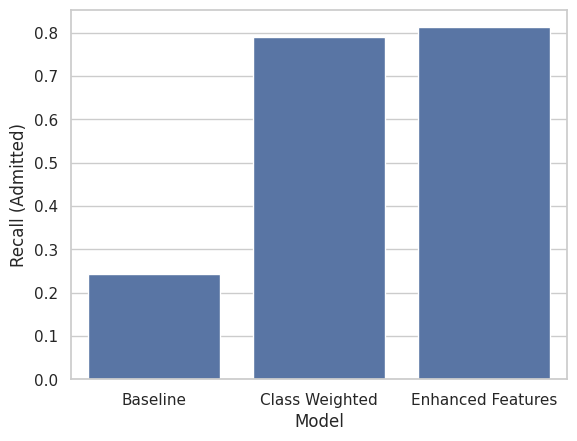

In [ ]:
results = pd.DataFrame({
    'Model': ['Baseline', 'Class Weighted', 'Enhanced Features'],
    'Recall (Admitted)': [recall_base, recall_w, recall_v2],
    'ROC-AUC': [
        roc_auc_score(y_val, y_val_prob_base),
        roc_auc_score(y_val, y_val_prob_w),
        roc_auc_score(y_val, y_val_prob_v2)
    ]
})

sns.barplot(data=results, x='Model', y='Recall (Admitted)')


results

## 6.6 Final Model Selection and Test Evaluation

The best-performing model (based on validation recall) is selected.

### 6.6.1  Prepare test data

In [ ]:
X_test_fe = df_fe.loc[X_test.index]

X_test_v2 = prepare_data(X_test_fe, features_v2)
X_test_v2 = X_test_v2.reindex(columns=X_train_v2.columns, fill_value=0)


### 6.6.2  Final evaluation (TEST — used once)

In [ ]:
y_test_pred = model_v2.predict(X_test_v2)
y_test_prob = model_v2.predict_proba(X_test_v2)[:, 1]

print(classification_report(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))



              precision    recall  f1-score   support

           0       0.97      0.74      0.84     47861
           1       0.30      0.81      0.43      6332

    accuracy                           0.75     54193
   macro avg       0.63      0.78      0.64     54193
weighted avg       0.89      0.75      0.79     54193

ROC-AUC: 0.8569376149185861


## 6.7 Saved Model

In [ ]:
model_path = "../models/model_iteration.pkl"
columns_path = "../models/model_columns.pkl"

with open(model_path, "rb") as f:
    model = pickle.load(f)

with open(columns_path, "rb") as f:
    model_columns = pickle.load(f)

## 6.8 Overall

The modeling process demonstrates a clear trade-off between predictive performance and practical utility.

The baseline model achieved strong overall accuracy and ROC-AUC, but performed poorly in identifying admitted patients, with very low recall. This highlights the limitation of standard models under class imbalance, where accuracy can be misleading.

By introducing class weighting, the model significantly improved recall for admitted cases, increasing from 0.24 to 0.79. This confirms that class imbalance was a key issue affecting model performance.

Further improvements were achieved through feature engineering. By incorporating contextual variables (e.g., weekend, alcohol, drug involvement, narrative length) and interaction effects, the final model reached a recall of 0.81 and an ROC-AUC of 0.857 on the test set.

Although precision remains relatively low, the model prioritizes recall, which aligns with the healthcare objective of minimizing missed high-risk patients.

Overall, the results show that:

* Addressing class imbalance is critical for improving model usefulness
* Feature engineering adds incremental but meaningful gains
* There is an inherent trade-off between recall and precision

The final model provides a practical and interpretable approach for early identification of high-risk patients, while also highlighting areas for further improvement.
